<a href="https://colab.research.google.com/github/athirasivadas94-glitch/MLAssesment/blob/main/ML_Assesment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Description:**

A Chinese automobile company aspires to enter the US market by setting up their manufacturing unit
there and producing cars locally to give competition to their US and European counterparts. They have
contracted an automobile consulting company to understand the factors on which the pricing of cars
depends. Specifically, they want to understand the factors affecting the pricing of cars in the American
market, since those may be very different from the Chinese market. Essentially, the company wants to
know:
Which variables are significant in predicting the price of a car?
How well those variables describe the price of a car?
Based on various market surveys, the consulting firm has gathered a large dataset of different types of
cars across the American market.

**Business Goal:**
You are required to model the price of cars with the available independent variables. It
will be used by the management to understand how exactly the prices vary with the independent
variables. They can accordingly manipulate the design of the cars, the business strategy, etc., to meet
certain price levels. Further, the model will be a good way for the management to understand the pricing
dynamics of a new market.

Dataset : https://drive.google.com/file/d/1FHmYNLs9v0Enc-UExEMpitOFGsWvB2dP/view?usp=drive_link

1. Loading and Preprocessing: Load the dataset and perform necessary preprocessing steps.

In [63]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [25]:
# Load dataset
df = pd.read_csv("CarPrice_Assignment.csv")

# Display first 5 rows
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [27]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [28]:
df.shape

(205, 26)

In [29]:
#Checking Missing Values
df.isnull().sum()
#In this dataset, there are no missing values, so no imputation is required.

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [30]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [31]:
# Dropping Unnecessary Columns
df.drop(['car_ID'], axis=1, inplace=True)

In [32]:
df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [33]:
#Extracting Car Brand from CarName
# The CarName column contains both brand and model names. Since the brand can influence the price, the brand name is extracted.

df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0])
df = df.drop(['CarName'], axis=1)

In [34]:
df.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [35]:
numeric_cols = df.select_dtypes(include=['int64','float64'])

numeric_cols.skew()

,0
symboling,0.211072
wheelbase,1.050214
carlength,0.155954
carwidth,0.904003
carheight,0.063123
curbweight,0.681398
enginesize,1.947655
boreratio,0.020156
stroke,-0.689705
compressionratio,2.610862


In [37]:
#Reduce skewness

df['price'] = np.log(df['price'])

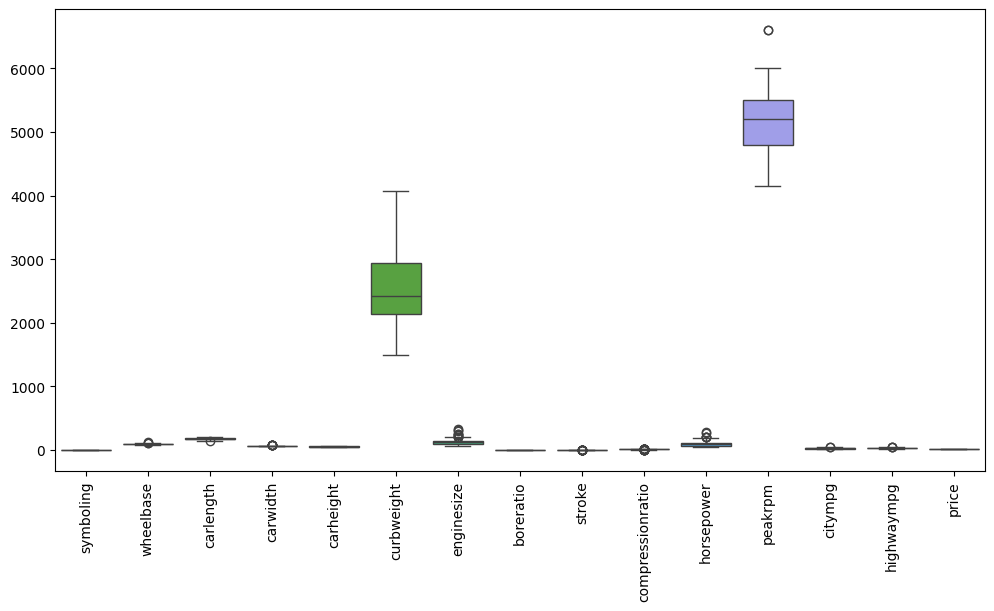

In [39]:
# Outlier Detection

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [41]:
#Encoding Categorical Variables
#Machine learning models require numerical input. Therefore, categorical variables are converted into numerical values using **scikit-learn encoding techniques.

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [42]:
# Feature and Target Separation
# The dataset is divided into independent variables (X) and target variable (Y)
X = df.drop('price', axis=1)
Y = df['price']

In [43]:
# Train-Test Split
# The dataset is divided into training and testing sets to evaluate model performance.
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [44]:
#Feature Scaling
#Some machine learning algorithms perform better when features are scaled. Feature scaling is done using StandardScaler.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

2. Model Implementation: Implement the following five regression algorithms:

● Linear Regression
● Decision Tree Regressor
● Random Forest Regressor
● Gradient Boosting Regressor
● Support Vector Regressor

**2.1  Linear Regression**

Linear Regression is one of the simplest regression algorithms. It models the relationship between the dependent variable (car price) and independent variables using a linear equation.

It assumes that the target variable changes linearly with the input features.

In [47]:
# Create model
lr = LinearRegression()

# Train model
lr.fit(X_train, Y_train)

# Prediction
y_pred_lr = lr.predict(X_test)

**2.2 Decision Tree Regressor**

Decision Tree Regressor splits the dataset into smaller subsets based on decision rules derived from the features. It creates a tree-like structure where each node represents a condition.

It is useful for capturing non-linear relationships in the data.

In [58]:
# Create model
dt = DecisionTreeRegressor(random_state=42)

# Train model
dt.fit(X_train, Y_train)

# Prediction
y_pred_dt = dt.predict(X_test)

**2.3 Random Forest Regressor**

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.


In [51]:
# Create model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf.fit(X_train, Y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

**2.4 Gradient Boosting Regressor**

Gradient Boosting builds models sequentially where each new model attempts to correct the errors made by the previous models. It is known for providing strong predictive performance.

In [53]:
# Create model
gb = GradientBoostingRegressor()

# Train model
gb.fit(X_train, Y_train)

# Prediction
y_pred_gb = gb.predict(X_test)


**2.5 Support Vector Regressor**

Support Vector Regressor (SVR) is based on Support Vector Machines. It tries to find a function that fits the data within a specified error margin. SVR works well for high-dimensional datasets.


In [55]:
# Create model
svr = SVR()

# Train model
svr.fit(X_train, Y_train)

# Prediction
y_pred_svr = svr.predict(X_test)

3. Model Evaluation : Compare the performance of all the models based on R-squared,
Mean Squared Error (MSE), and Mean Absolute Error (MAE). Identify the best performing model
and justify why it is the best.

1. R-squared (R²)

R² measures how well the independent variables explain the variance in the target variable.

Value ranges between 0 and 1

Higher value indicates better model performance

2. Mean Squared Error (MSE)

MSE calculates the average squared difference between the predicted and actual values.

Lower MSE indicates better performance

3. Mean Absolute Error (MAE)

MAE measures the average absolute difference between predicted and actual values.

Lower MAE indicates more accurate predictions

These metrics were calculated using functions from scikit-learn.

In [60]:
#Model Evaluation
# Linear Regression
lr_r2 = r2_score(Y_test, y_pred_lr)
lr_mse = mean_squared_error(Y_test, y_pred_lr)
lr_mae = mean_absolute_error(Y_test, y_pred_lr)

# Decision Tree
dt_r2 = r2_score(Y_test, y_pred_dt)
dt_mse = mean_squared_error(Y_test, y_pred_dt)
dt_mae = mean_absolute_error(Y_test, y_pred_dt)

# Random Forest
rf_r2 = r2_score(Y_test, y_pred_rf)
rf_mse = mean_squared_error(Y_test, y_pred_rf)
rf_mae = mean_absolute_error(Y_test, y_pred_rf)

# Gradient Boosting
gb_r2 = r2_score(Y_test, y_pred_gb)
gb_mse = mean_squared_error(Y_test, y_pred_gb)
gb_mae = mean_absolute_error(Y_test, y_pred_gb)

# Support Vector Regressor
svr_r2 = r2_score(Y_test, y_pred_svr)
svr_mse = mean_squared_error(Y_test, y_pred_svr)
svr_mae = mean_absolute_error(Y_test, y_pred_svr)

In [61]:
# Model Comparison
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Support Vector Regressor"
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        svr_r2
    ],
    "MSE": [
        lr_mse,
        dt_mse,
        rf_mse,
        gb_mse,
        svr_mse
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        gb_mae,
        svr_mae
    ]
})

print(results)

                      Model  R2 Score       MSE       MAE
0         Linear Regression  0.881272  0.032214  0.134705
1             Decision Tree  0.860846  0.037756  0.144997
2             Random Forest  0.946524  0.014509  0.099673
3         Gradient Boosting  0.934713  0.017714  0.113233
4  Support Vector Regressor  0.849911  0.040723  0.149377


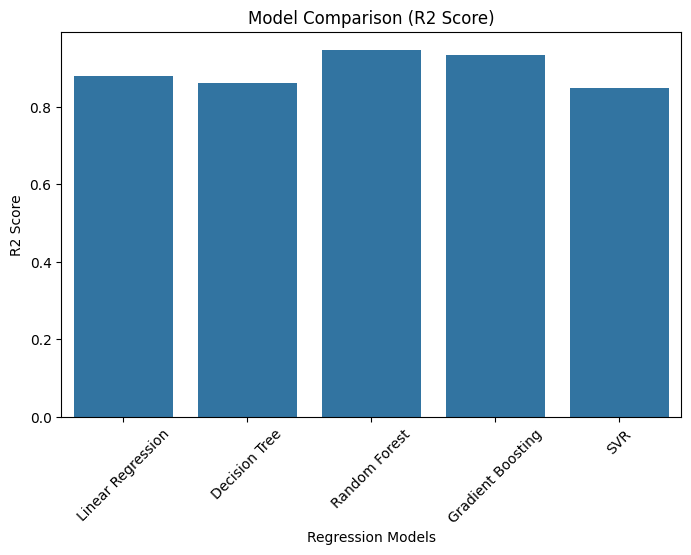

In [68]:
models = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "SVR"
]

r2_scores = [
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        svr_r2
]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=r2_scores)

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xlabel("Regression Models")
plt.xticks(rotation=45)

plt.show()

The Random Forest Regressor performed the best among all the models.

Justification

It achieved the highest R² score (0.9465), indicating that it explains about 94.65% of the variance in car prices.

It has the lowest Mean Squared Error (0.014509), meaning the predictions have the smallest squared error.

It also has the lowest Mean Absolute Error (0.099673), showing that the predicted prices are very close to the actual prices.

Random Forest performs well because it is an ensemble learning method that combines multiple decision trees to reduce variance and improve prediction accuracy.

4. Feature Importance Analysis: Identify the significant variables affecting car prices
(feature selection)

In [62]:

# Get feature importance from Random Forest model
importances = rf.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

             Feature    Importance
11        curbweight  5.980741e-01
14        enginesize  1.411214e-01
22        highwaympg  1.153002e-01
19        horsepower  4.840582e-02
23             brand  1.778337e-02
21           citympg  1.305864e-02
8          carlength  1.105235e-02
9           carwidth  1.032929e-02
7          wheelbase  9.033618e-03
17            stroke  5.529308e-03
15        fuelsystem  5.108595e-03
4            carbody  4.676788e-03
20           peakrpm  4.364927e-03
10         carheight  4.025328e-03
16         boreratio  3.095665e-03
18  compressionratio  2.468668e-03
0          symboling  1.540009e-03
12        enginetype  1.318739e-03
3         doornumber  1.248543e-03
2         aspiration  9.670030e-04
5         drivewheel  9.080630e-04
1           fueltype  3.086706e-04
13    cylindernumber  2.805209e-04
6     enginelocation  4.282698e-07


The results show that curbweight is the most influential variable with an importance score of 0.598, indicating that the weight of the car plays a major role in determining its price.

Other important variables include:

enginesize (0.141)

highwaympg (0.115)

horsepower (0.048)

brand (0.017)

These variables significantly affect the price because they are related to engine performance, fuel efficiency, and vehicle design, which influence manufacturing cost and market value.

5. Hyperparameter Tuning: Perform hyperparameter tuning and check whether the
performance of the model has increased.

Hyperparameter tuning is the process of optimizing the parameters of a machine learning model to improve its performance. In this project, hyperparameter tuning was performed on the Random Forest Regressor, since it was the best-performing model.

The tuning process was carried out using GridSearchCV from scikit-learn, which searches for the best combination of parameters by evaluating multiple models.

In [64]:
#Hyperparameter Tuning

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train GridSearch
grid_search.fit(X_train, Y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [67]:
#Train Model with Best Parameters
best_rf = grid_search.best_estimator_

# Prediction
y_pred_tuned = best_rf.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Tuned R2:", r2_score(Y_test, y_pred_tuned))
print("Tuned MSE:", mean_squared_error(Y_test, y_pred_tuned))
print("Tuned MAE:", mean_absolute_error(Y_test, y_pred_tuned))

Tuned R2: 0.9465236603566515
Tuned MSE: 0.01450949042133699
Tuned MAE: 0.09967304502136914


The tuned model produced the same performance metrics as the original Random Forest model, indicating that the default parameters were already optimal for this dataset. Therefore, hyperparameter tuning did not significantly improve the model performance, but it confirmed that the model was already well-optimized.

**Project Conclusion**

In this project, a machine learning model was developed to predict car prices based on various automobile features. The dataset was first preprocessed by handling duplicates, checking skewness, analyzing outliers, and encoding categorical variables using pandas and scikit-learn.

Five regression algorithms were implemented: Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and Support Vector Regressor. The models were evaluated using R² Score, Mean Squared Error (MSE), and Mean Absolute Error (MAE).

Among all models, Random Forest Regressor performed the best, achieving the highest R² score and the lowest error values. Feature importance analysis revealed that curb weight, engine size, highway mileage, and horsepower are the most significant factors affecting car prices.

Hyperparameter tuning was also performed to optimize the model, confirming that the Random Forest model already had optimal performance. Overall, the developed model helps understand the key factors influencing car pricing in the American automobile market.